In [ ]:
from google.colab import files
files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
# S1
def email_len(email_row_col):
  return len(email_row_col)

test_df['text_length'] = test_df['text'].apply(email_len)

In [ ]:
S1 = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test_df['sample_id'],
    'answer': test_df['text_length'],
})

S1.head()

,subtaskID,datapointID,answer
0,1,75707,237
1,1,4026,946
2,1,2156,1554
3,1,49593,1207
4,1,23028,1684


In [ ]:
test_df.head()

,sample_id,text,text_length
0,75707,just take a look at this one target sym wdscpr...,237
1,4026,- - - - - original message - - - - -\nfrom : s...,946
2,2156,yours argue science sudden as wanted journey s...,1554
3,49593,vince : a minor revision of my earlier email s...,1207
4,23028,but not always for example i can partake with ...,1684


In [ ]:
# S2
import re

def free_count(email_row_col):
  if pd.isna(email_row_col):
    return 0

  text_lower = str(email_row_col).lower()
  return len(re.findall(r'\bfree\b', text_lower))

test_df['free_count'] = test_df['text'].apply(free_count)

In [ ]:
test_df.head()

,sample_id,text,text_length,free_count
0,75707,just take a look at this one target sym wdscpr...,237,0
1,4026,- - - - - original message - - - - -\nfrom : s...,946,0
2,2156,yours argue science sudden as wanted journey s...,1554,1
3,49593,vince : a minor revision of my earlier email s...,1207,0
4,23028,but not always for example i can partake with ...,1684,0


In [ ]:
S2 = pd.DataFrame({
    'subtaskID': 2,
    'datapointID': test_df['sample_id'],
    'answer': test_df['free_count'],
})

S2.head()

,subtaskID,datapointID,answer
0,2,75707,0
1,2,4026,0
2,2,2156,1
3,2,49593,0
4,2,23028,0


In [ ]:
S2.answer.value_counts().head(3)

,count
answer,
0,14710
1,1416
2,312


In [ ]:
test_df.iloc[2]['text']

'yours argue science sudden as wanted journey sign certain gym fool safe effective penisenlargement over escapenumber escapenumber escapenumber bottles soldworldwide weoffer a full money back guarantee if you are not completely satisfied with the results of man xl you have nothing to lose just a lot to gain a breakthrough in herbal science has created a pill that has been designed specifically for penisenlargement the tests that took place over a escapenumber month period showed that out of the escapenumber escapenumber males from around the world who participated the average gain after escapenumber months of taking man xl pills was escapenumber escapenumber inches amazing permanent results that will last did you know man xl was featured in leading mens magazines such as fhm maxim plus many others and rated no escapenumber choice forpenisenlargement also seen on tv gain up to escapenumber inches in length increase yourpenis width girth by upto escapenumber help stop escapelong produce 

In [ ]:
all_text = "".join(train_df['text'].dropna()) + "".join(test_df['text'].dropna())
chars = sorted(list(set(all_text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !"#$%&'()*+,-./0123456789:;<=>?@[\]^_`abcdefghijklmnopqrstuvwxyz{|}~¡¢£¤¥¦§¨©ª«¬­®¯°±²³´µ¶·¸¹º»¼½¾¿À×ÜÝÞßàáâãäåæçèéêëìíîïðñòóôõö÷øùúûüýþÿćčęğīłńœśżșɤ̇ͨβθπабвгдежзиклмнопрстухцчшщъьэюяёђѕњќӿאבוחילםמנפרשתثڶṁ–—‘’“”†‡•…⁄€№™−∷⌂☺♣✗。みむもシデモュリルン・ㄞㄢ上世中享件俊信写劎大子小我拒文最李杰楊用电界的系统膄膅膆道邮ﬁ（）￼�
328


In [ ]:
stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s] # string -> integer
decode = lambda l: ''.join([itos[i] for i in l])

encode('etc.')

[63, 78, 61, 34]

In [ ]:
def email_encode(email_row_col):
  return encode(email_row_col)

test_df['encoded_text'] = test_df['text'].apply(email_encode)

In [ ]:
len(test_df.iloc[1]['encoded_text'])

946

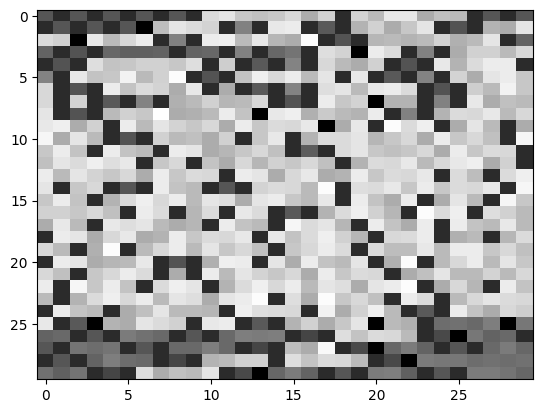

In [ ]:
data_2d = np.reshape(test_df.iloc[1]['encoded_text'][:900], (30,30))
plt.imshow(data_2d, cmap='gray', aspect='auto')

In [ ]:
test_df.head()

,sample_id,text,text_length,free_count,encoded_text
0,75707,just take a look at this one target sym wdscpr...,237,0,"[68, 79, 77, 78, 20, 78, 59, 69, 63, 20, 59, 2..."
1,4026,- - - - - original message - - - - -\nfrom : s...,946,0,"[33, 20, 33, 20, 33, 20, 33, 20, 33, 20, 73, 7..."
2,2156,yours argue science sudden as wanted journey s...,1554,1,"[83, 73, 79, 76, 77, 20, 59, 76, 65, 79, 63, 2..."
3,49593,vince : a minor revision of my earlier email s...,1207,0,"[80, 67, 72, 61, 63, 20, 46, 20, 59, 20, 71, 6..."
4,23028,but not always for example i can partake with ...,1684,0,"[60, 79, 78, 20, 72, 73, 78, 20, 59, 70, 81, 5..."


In [ ]:
train_df['label'].value_counts()

,count
label,
1,35128
0,31630


In [ ]:
# S3
from sklearn.feature_extraction.text import TfidfVectorizer

X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']

vectorizer = TfidfVectorizer(lowercase=True, sublinear_tf=True)

X_train_trans = vectorizer.fit_transform(X_train)
X_test_trans = vectorizer.transform(X_test)

In [ ]:
len(vectorizer.get_feature_names_out())

275417

In [ ]:
# RandomForestClassifier init. + training <--> I option (~0.623 ROC)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(verbose=1, n_jobs=-1, max_depth=20, n_estimators=500)

model.fit(X_train_trans, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   10.7s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   38.0s
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.6min finished


RandomForestClassifier(max_depth=20, n_estimators=500, n_jobs=-1, verbose=1)

In [ ]:
y_preds = model.predict(X_test_trans)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.6s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    8.8s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    9.8s finished


In [ ]:
# Light Gradient Boosting Model init. + training <--> II option (way better ~ 0.99 ROC)

import lightgbm as lgb

model2 = lgb.LGBMClassifier(n_estimators=500, n_jobs=-1, objective='binary', verbose=1)

model2.fit(X_train_trans, y_train)

[LightGBM] [Info] Number of positive: 35128, number of negative: 31630
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 32.152529 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1245779
[LightGBM] [Info] Number of data points in the train set: 66758, number of used features: 23421
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526199 -> initscore=0.104892
[LightGBM] [Info] Start training from score 0.104892


LGBMClassifier(n_estimators=500, n_jobs=-1, objective='binary', verbose=1)

In [ ]:
y_preds2 = model2.predict(X_test_trans)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
pd.DataFrame(y_preds2).value_counts()

,count
0,
1,8821
0,7869


In [ ]:
S3 = pd.DataFrame({
    'subtaskID': 3,
    'datapointID': test_df['sample_id'],
    'answer': y_preds2,
})

S3.head()

,subtaskID,datapointID,answer
0,3,75707,1
1,3,4026,0
2,3,2156,1
3,3,49593,0
4,3,23028,1


In [ ]:
submission = pd.concat([S1,S2,S3])
submission.to_csv('submission.csv', index=False)

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>